# Task 1 — LSTM Next-Word Prediction

### Introduction
Language Modeling is a fundamental sequence task where the goal is to predict the probability distribution of the next word given a preceding sequence of words:
$$P(w_t \mid w_1, w_2, ..., w_{t-1})$$

In this notebook, we implement a word-level language model using an LSTM network in PyTorch. The model processes input tokens, updates its recurrent hidden state to hold the history representation, and uses a Fully Connected layer over the vocabulary indices to classify the next word.

We train this model on a creative story so that it learns the sequence of words and can predict subsequent tokens for a creative prediction task.

We also build an interactive user interface directly inside the notebook using `ipywidgets` to test the trained model on custom inputs!

### Core Use Cases
- **Creative Writing Assistants**: Drafting stories or articles word-by-word.
- **Autofill and Keyboards**: Suggesting the next words on mobile text inputs.



### Step 1 — Build the Next-Word Dataset Pipeline


In [1]:
import re
import os
import json
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# A creative sci-fi story about a tiny explorer robot
corpus = """
once upon a time in a distant galaxy there was a small robot named sparky . 
sparky loved to explore ancient planets and search for glowing blue crystals . 
one day sparky found a hidden cave on a mysterious planet . 
inside the cave sparky discovered a golden portal that was glowing with magical energy . 
sparky took a deep breath and stepped into the golden portal . 
suddenly sparky was transported to a beautiful forest filled with giant glowing trees and singing animals . 
the robot realized that its grand adventure had just begun . 
"""

# Tokenize corpus to lowercased words using regex
words = re.findall(r'\b\w+\b', corpus.lower())

unique_words = sorted(list(set(words)))
word_to_ix = {word: idx + 2 for idx, word in enumerate(unique_words)}
word_to_ix['<PAD>'] = 0
word_to_ix['<UNK>'] = 1
ix_to_word = {idx: word for word, idx in word_to_ix.items()}

vocab_size = len(word_to_ix)

# Sequence generation sliding window
seq_len = 4
inputs = []
targets = []

word_indices = [word_to_ix[w] for w in words]
for i in range(len(word_indices) - seq_len):
    inputs.append(word_indices[i : i + seq_len])
    targets.append(word_indices[i + seq_len])

X_train = torch.tensor(inputs, dtype=torch.long)
y_train = torch.tensor(targets, dtype=torch.long)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Export vocabulary data for potential external integrations
outputs_dir = "outputs"
os.makedirs(outputs_dir, exist_ok=True)
vocab_data = {
    'word_to_ix': word_to_ix,
    'ix_to_word': {str(idx): word for idx, word in ix_to_word.items()},
    'seq_len': seq_len
}
with open(os.path.join(outputs_dir, "vocab.json"), "w", encoding="utf-8") as f:
    json.dump(vocab_data, f, indent=1, ensure_ascii=False)

print(f"Total tokens: {len(words)}")
print(f"Unique words (vocab size): {vocab_size}")
print(f"Training sequence count: {len(X_train)}")



Total tokens: 89
Unique words (vocab size): 64
Training sequence count: 85


### Step 2 — Define Next-Word LSTM Predictor Architecture


In [2]:
class NextWordLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(NextWordLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        out, (h, c) = self.lstm(embedded)
        # Classify using the last sequence step output
        last_out = out[:, -1, :]
        logits = self.fc(last_out)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NextWordLSTM(vocab_size, embed_dim=64, hidden_dim=64).to(device)
print(model)



NextWordLSTM(
  (embedding): Embedding(64, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=64, bias=True)
)


### Step 3 — Train LSTM Predictor & Plot Loss Curve


Training model...
Epoch 15/120 - Train Loss: 0.0295
Epoch 30/120 - Train Loss: 0.0079
Epoch 45/120 - Train Loss: 0.0039
Epoch 60/120 - Train Loss: 0.0022
Epoch 75/120 - Train Loss: 0.0014
Epoch 90/120 - Train Loss: 0.0010
Epoch 105/120 - Train Loss: 0.0007
Epoch 120/120 - Train Loss: 0.0006
Model saved to outputs/next_word_lstm.pt


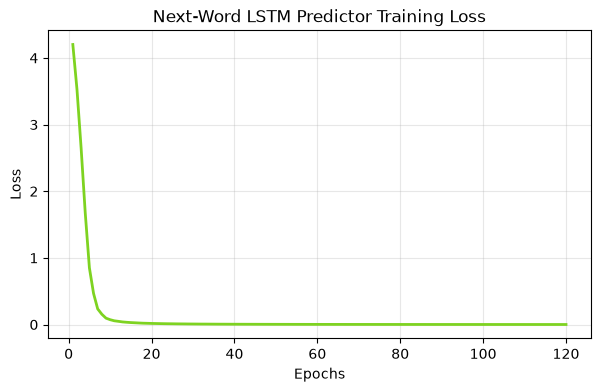

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

epochs = 120
losses = []

print("Training model...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 15 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}")

# Save the trained model weights
save_data = {
    'state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'embed_dim': 64,
    'hidden_dim': 64
}
torch.save(save_data, os.path.join(outputs_dir, "next_word_lstm.pt"))
print("Model saved to outputs/next_word_lstm.pt")

# Plot loss
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs+1), losses, color='#7ED321', linewidth=2)
plt.title("Next-Word LSTM Predictor Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.savefig("outputs/next_word_loss.png")
plt.show()



### Step 4 — Interactive In-Notebook Prediction Interface
Type a prompt (at least 1-4 words) in the text box below. The interface will display the top-3 predictions and let you append the word you want to write!


In [4]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

def get_predictions(seed_text, top_k=3):
    model.eval()
    seed_words = re.findall(r'\b\w+\b', seed_text.lower())
    encoded = [word_to_ix.get(w, 1) for w in seed_words]
    
    if len(encoded) < seq_len:
        encoded = [0] * (seq_len - len(encoded)) + encoded
    else:
        encoded = encoded[-seq_len:]
        
    in_tensor = torch.tensor([encoded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(in_tensor)
        probs = torch.softmax(logits, dim=-1).squeeze()
        
    top_probs, top_ixs = torch.topk(probs, top_k)
    results = []
    for p, ix in zip(top_probs, top_ixs):
        results.append((ix_to_word[ix.item()], p.item()))
    return results

# Interactive UI Components
input_text = widgets.Text(
    value="once upon a time",
    placeholder="Type a sequence of words here...",
    description="Seed:",
    layout=widgets.Layout(width="60%")
)

predict_btn = widgets.Button(
    description="Predict Next Word",
    button_style="primary",
    icon="magic",
    layout=widgets.Layout(width="20%")
)

suggestion_box = widgets.HBox([])
output_area = widgets.Output()

def update_ui(b=None):
    with output_area:
        clear_output()
        prompt = input_text.value.strip()
        if not prompt:
            print("Please enter some seed text.")
            return
            
        preds = get_predictions(prompt)
        
        # Create suggestion buttons dynamically
        buttons = []
        for word, prob in preds:
            btn = widgets.Button(
                description=f"'{word}' ({prob*100:.1f}%)",
                button_style="success",
                layout=widgets.Layout(margin="5px")
            )
            def click_handler(w=word):
                input_text.value = input_text.value.strip() + " " + w
                update_ui()
            btn.on_click(lambda click_evt, w=word: click_handler(w))
            buttons.append(btn)
            
        suggestion_box.children = buttons
        
        print(f"Seed context: '{prompt}'")
        print("-" * 50)
        for idx, (word, prob) in enumerate(preds):
            print(f" {idx+1}. Suggestion: '{word}' | Confidence: {prob*100:.2f}%")

predict_btn.on_click(update_ui)
update_ui()

ui_layout = widgets.VBox([
    widgets.HTML("<h3>Interactive Typing Suggester</h3>"),
    widgets.HTML("<p>Type a prompt and click a green button to append that word to your seed sentence.</p>"),
    widgets.HBox([input_text, predict_btn]),
    widgets.HTML("<h4>Top Predictions (Click to append):</h4>"),
    suggestion_box,
    output_area
])

display(ui_layout)

